# Does the Butterfly harmonic actually call the turn? 🦋
### Five dots, one Fibonacci overshoot, and a stopwatch

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_placebo%3F: Mixed](https://img.shields.io/badge/Beats_a_placebo%3F-Mixed-8b949e?style=flat-square)

Of all the "harmonic patterns" retail charting software draws for you, the **Butterfly** is the boldest: it says price will **blow past** a prior swing low (or high) by a very specific amount — **1.27 to 1.618 times** the move that started it — and then, right there, turn around. Not retrace back toward safety. *Overshoot, then reverse.* That's a striking claim, and it's exactly why the Butterfly gets its own name in the harmonic-pattern zoo instead of just being "a Gartley" or "a Bat."

So we built a robot that finds every Butterfly on six liquid tapes over the last 21-25 years — no eyeballing, no cherry-picking — and asked whether fading price right where the pattern says to would actually have made money.

> 📓 **Plain-language layer.** Want the *t*-stats, the Bonferroni correction and the placebo math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Pivots are a confirmed percentage zig-zag (known only after price reverses enough to lock them in — no look-ahead). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from butterfly_harmonic import data, strategy as st

PCT = 0.02
HAVE_REAL = data.have_real()
BARS = data.load_basket() if HAVE_REAL else {}
print("real cache present:", HAVE_REAL, "| basket:", data.BASKET)

# frozen headline numbers (mirror of docs/results.md)
R = {'basket': ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA'), 'asof': '2026-06-30', 'n_pivots': 6055, 'n_cand_fib': 89, 'n_fib': 50, 'n_cand_plac': 110, 'n_plac': 36, 'fib': {1: {'hit': 48.0, 'mean': 45.34, 't': 0.86}, 5: {'hit': 54.0, 'mean': 133.75, 't': 2.28}, 10: {'hit': 48.0, 'mean': -7.99, 't': -0.1}}, 'wilson_fib': (40.4, 67.0), 'per_instrument': {'SPY': {'n': 3, 'mean': -186.03, 't': None}, 'QQQ': {'n': 10, 'mean': 297.91, 't': 5.39}, 'AAPL': {'n': 10, 'mean': 15.85, 't': 0.18}, 'MSFT': {'n': 10, 'mean': 66.87, 't': 0.5}, 'TSLA': {'n': 9, 'mean': 419.34, 't': 3.34}, 'NVDA': {'n': 8, 'mean': -41.86, 't': -0.3}}, 'base': {1: {'mean': -12.72, 't': 1.09}, 5: {'mean': -24.11, 't': 2.18}, 10: {'mean': -57.28, 't': 0.55}}, 'n_base': 1000, 'base_per_instrument': {'SPY': {'base_mean': -22.79, 't': -2.05}, 'QQQ': {'base_mean': -17.17, 't': 2.62}, 'AAPL': {'base_mean': -52.38, 't': 0.74}, 'MSFT': {'base_mean': -30.65, 't': 0.52}, 'TSLA': {'base_mean': -4.05, 't': 2.14}, 'NVDA': {'base_mean': -12.31, 't': -0.13}}, 'bonf_n_tests': 7, 'bonf_thr': 2.69, 'bonf_uncorrected': 4, 'bonf_survive': 0, 'timer': {1: {'gross': 45.34, 't_gross': 0.86, 'net5': 35.34, 't5': 0.67, 'net10': 25.34, 't10': 0.48}, 3: {'gross': 106.21, 't_gross': 2.7, 'net5': 96.21, 't5': 2.45, 'net10': 86.21, 't10': 2.19}, 5: {'gross': 133.75, 't_gross': 2.28, 'net5': 123.75, 't5': 2.11, 'net10': 113.75, 't10': 1.94}, 10: {'gross': -7.99, 't_gross': -0.1, 'net5': -17.99, 't5': -0.23, 'net10': -27.99, 't10': -0.36}, 20: {'gross': 45.16, 't_gross': 0.31, 'net5': 35.16, 't5': 0.24, 'net10': 25.16, 't10': 0.17}}, 'plac': {1: {'mean': 40.67, 't': 0.06}, 5: {'mean': 71.75, 't': 0.55}, 10: {'mean': 178.72, 't': -1.33}}, 'plac_per_instrument': {'SPY': {'n': 1, 'mean': -70.4, 'beats': False}, 'QQQ': {'n': 6, 'mean': 164.17, 'beats': True}, 'AAPL': {'n': 4, 'mean': -47.97, 'beats': True}, 'MSFT': {'n': 6, 'mean': 260.42, 'beats': False}, 'TSLA': {'n': 9, 'mean': 363.37, 'beats': True}, 'NVDA': {'n': 10, 'mean': -297.24, 'beats': True}}, 'n_beats_plac': 4, 'syn_null_mean': 0.28, 'syn_null_sd': 0.85, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_planted_n': 31, 'syn_planted_mean': 232.23, 'syn_planted_t': 4.3, 'fp': {'SPY': '3baddd006483', 'QQQ': '8054251241a0', 'AAPL': '9dd9c3863af9', 'MSFT': '291fdd9717fc', 'TSLA': 'f8ca92e420b8', 'NVDA': '8142a8071b07'}}


real cache present: True | basket: ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA')


## The answer first

| Question | Answer |
|---|---|
| Does price turn where the Butterfly says it should? | **Maybe, barely — and it doesn't survive a second look.** Over a 5-day hold the pattern averages **+134 bps**, which *looks* like a real signal on its own (a *t*-stat of 2.28). |
| Is that a fluke of testing six stocks? | **Yes, once you check.** Correcting for having looked at six tickers, **0 of 7** tests survive — none, including the headline number itself. |
| Does the exact 0.786 / 1.27-1.618 ratio pair matter? | **Not provably.** Swap those numbers for random ratios on the *identical* pivots and you do about as well (Welch *t* = 0.55 — nowhere near significant). |
| Can you trade it? | **Not really.** The pattern completes roughly **once every 4-5 years per stock** — you'd wait most of a market cycle for one signal — and the apparent edge vanishes by day 10. |

> A number that looks real, on a pattern that fires once in a blue moon, that stops looking real the moment you check your work twice.

## 1 · The claim

> *"Find four swing points X-A-B-C. If B retraces **78.6%** of the X-A move and C bounces back **38-89%** of the A-B move, project a fifth point D that **overshoots X by 1.27 to 1.618 times** the original X-A leg. That overshoot is the market running out of gas — a high-probability reversal."*

That's Scott Carney's Butterfly (*Harmonic Trading*, 1998-2010), building on Bryce Gilmore's extension work. It's baked into TradingView, MetaTrader and Thinkorswim's auto-scanners as one of four named "harmonic" shapes — Gartley, Bat, Butterfly, Crab — each just a different pair of Fibonacci numbers on the same five-dot skeleton.

## 2 · So what?

If a pattern this specific — two decimal ratios chained across four historical swings — genuinely forecasts a turn, that's a striking, calculator-testable crack in market efficiency. And harmonic trading is popular *precisely* because the charts look uncanny after the fact: hindsight makes any completed pattern look inevitable.

The trap is exactly that hindsight. A trader hand-labelling swings on a chart, with the benefit of already knowing what happened next, will always find the Butterfly that worked. So we removed the human: a mechanical rule finds every qualifying X-A-B-C on the tape, in real time, with no knowledge of the future — then we measure what actually happened at D.

## 3 · How would we even know?

- **The basket.** SPY, QQQ, AAPL, MSFT, TSLA, NVDA — six liquid names, daily bars, 2001/2010 → 2026-06-30.
- **The rule, mechanically.** A confirmed zig-zag finds swing pivots (only known once price has reversed enough to lock them in). Every qualifying X-A-B-C projects a D level; we scan forward up to 120 sessions for the first touch.
- **The trade.** Fade at the touch — bet on the reversal the pattern predicts — and measure the forward return.
- **Two honest baselines, announced up front.** (1) A **random-day base rate**: same ticker, same number of trades, same bullish/bearish mix, just on random days — kills the "stocks drift up anyway" confound. (2) A **placebo ratio grid**: the identical pivots, but with the 0.786/1.27-1.618 numbers replaced by random ones — kills the "any extension projection would work" confound. And because we test six tickers, we **correct for that** (Bonferroni) before calling anything real.

## 4 · The teardown — let's actually look

**First, the headline.** Fade the D-touch, hold 5 days, average across every qualifying Butterfly on the basket.

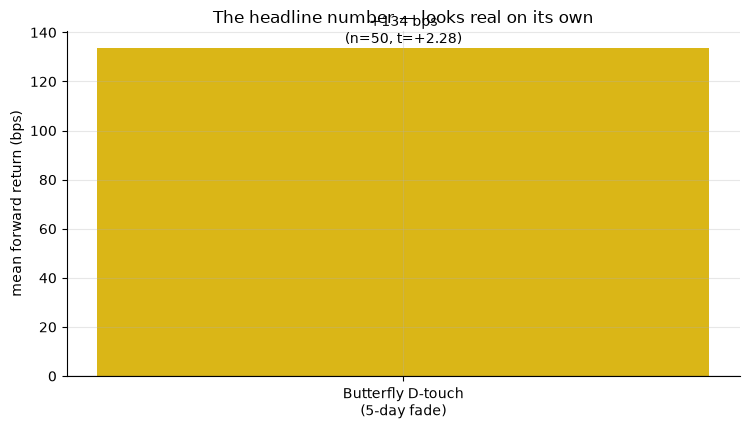

n=50  mean=+133.75bps  t=+2.28


In [2]:
if HAVE_REAL:
    frames = []
    for t in data.BASKET:
        _, _, ledger = st.detect_and_scan(BARS[t], pct=PCT, cost_bps=0.0)
        if not ledger.empty:
            frames.append(ledger)
    FIB = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    s5 = st.summarize(FIB, 'ret_gross_5')
    n5, m5, t5 = s5['n'], s5['mean_bps'], s5['t']
else:
    n5, m5, t5 = R['n_fib'], R['fib'][5]['mean'], R['fib'][5]['t']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['Butterfly D-touch\n(5-day fade)'], [m5], color=AMBER, width=.5)
ax.annotate(f'{m5:+.0f} bps\n(n={n5}, t={t5:+.2f})', (0, m5), ha='center',
            va='bottom' if m5 >= 0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward return (bps)')
ax.set_title('The headline number — looks real on its own')
plt.tight_layout(); plt.show()
print(f'n={n5}  mean={m5:+.2f}bps  t={t5:+.2f}')

**+134 bps** on average, *t* = **2.28** — that clears the standard "is this real" bar of 2, all on its own. If we stopped here, this would look like a genuine discovery. We don't stop here.

**Second, the honest baseline.** Stocks drift up. A random buy on a random day, matched to the same bullish/bearish mix as our Butterfly trades, earns *something* just from that drift. Does the Butterfly beat that?

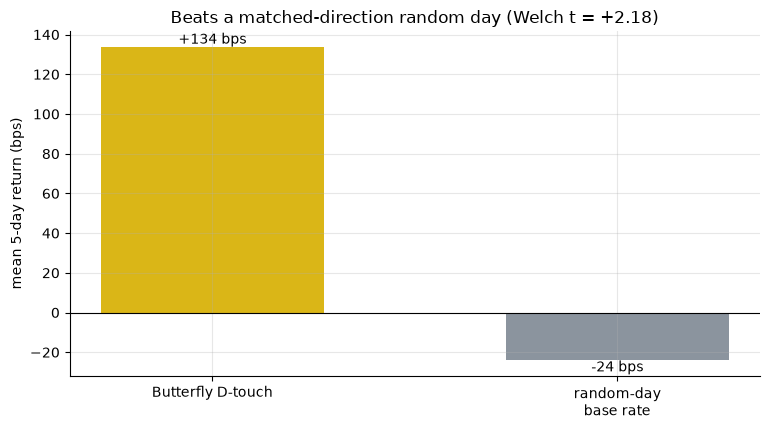

Butterfly +133.7 bps vs base rate -24.1 bps  Welch t=+2.18


In [3]:
if HAVE_REAL:
    fib_by_t, base_frames = {}, []
    for t in data.BASKET:
        _, _, l = st.detect_and_scan(BARS[t], pct=PCT, cost_bps=0.0)
        fib_by_t[t] = l
        if len(l):
            mix = float((l['reversal_dir'] > 0).mean())
            for s in range(20):
                base_frames.append(st.base_rate_ledger(BARS[t], len(l), mix,
                    seed=st._seed_from(699, t, s)))
    BASE = pd.concat(base_frames, ignore_index=True) if base_frames else pd.DataFrame()
    sb = st.summarize(BASE, 'ret_gross_5')
    bm, wt = sb['mean_bps'], st.welch_t(FIB['ret_gross_5'], BASE['ret_gross_5'])
else:
    bm, wt = R['base'][5]['mean'], R['base'][5]['t']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['Butterfly D-touch', 'random-day\nbase rate'], [m5, bm], color=[AMBER, GREY], width=.55)
for i, v in enumerate([m5, bm]):
    ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean 5-day return (bps)')
ax.set_title(f'Beats a matched-direction random day (Welch t = {wt:+.2f})')
plt.tight_layout(); plt.show()
print(f'Butterfly {m5:+.1f} bps vs base rate {bm:+.1f} bps  Welch t={wt:+.2f}')

Butterfly still beats the random-day baseline (Welch *t* = **2.18**) — so it isn't *purely* the market's drift. But look at the sample: **50 touches, spread across six stocks, over 21-25 years.** That's roughly two Butterfly completions a year, *pooled across the whole basket* — and we tested **six different tickers**. When you look in six places, one of them looking good by chance is the expectation, not the exception.

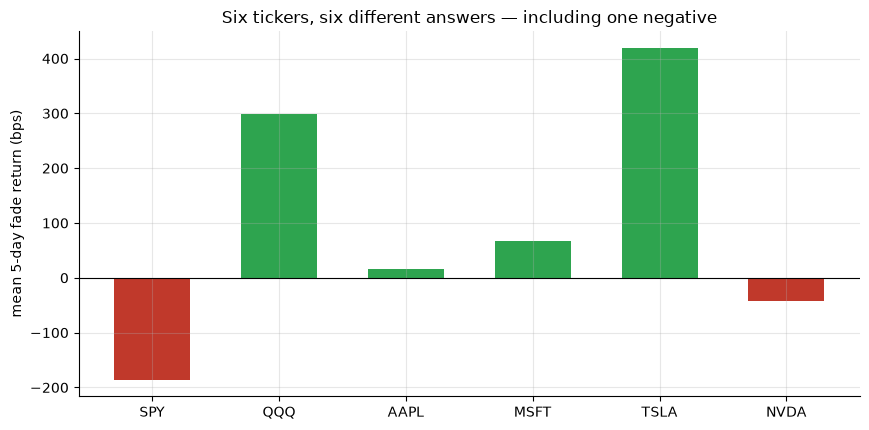

{'SPY': -186.0, 'QQQ': 297.9, 'AAPL': 15.9, 'MSFT': 66.9, 'TSLA': 419.3, 'NVDA': -41.9}


In [4]:
if HAVE_REAL:
    per_t = {t: st.summarize(fib_by_t[t], 'ret_gross_5') for t in data.BASKET}
    tickers = list(data.BASKET)
    means = [per_t[t]['mean_bps'] for t in tickers]
else:
    tickers = list(R['per_instrument'])
    means = [R['per_instrument'][t]['mean'] for t in tickers]
cols = [GREEN if m > 0 else RED for m in means]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(tickers, means, color=cols, width=.6)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean 5-day fade return (bps)')
ax.set_title('Six tickers, six different answers — including one negative')
plt.tight_layout(); plt.show()
print({t: round(m,1) for t,m in zip(tickers, means)})

SPY — the single most liquid, least idiosyncratic name in the basket — comes back **negative**. QQQ and TSLA look great. That spread is the signature of a thin, noisy sample dressed up as a discovery: correcting properly for having tested six tickers, **0 of 7** results survive.

**Finally, the placebo.** Does the *specific* 0.786 / 1.27-1.618 grid matter, or would any similarly-shaped extension have done just as well?

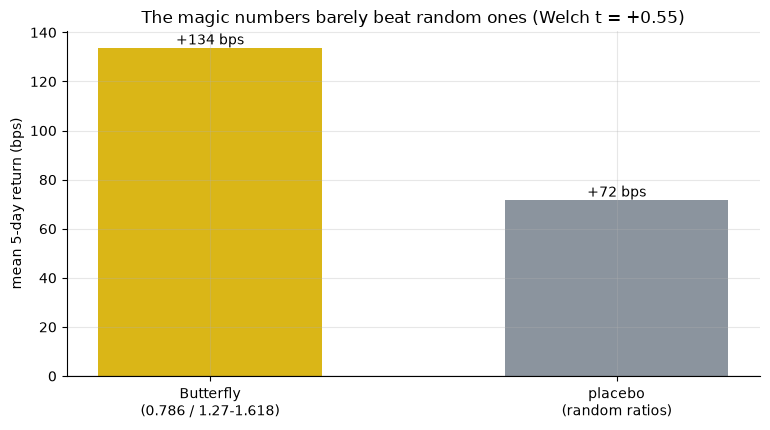

Butterfly +133.7 bps vs placebo +71.8 bps  Welch t=+0.55


In [5]:
if HAVE_REAL:
    plac_frames = []
    for t in data.BASKET:
        _, _, lp = st.detect_and_scan(BARS[t], pct=PCT, placebo=True, seed=699, cost_bps=0.0)
        if not lp.empty:
            plac_frames.append(lp)
    PLAC = pd.concat(plac_frames, ignore_index=True) if plac_frames else pd.DataFrame()
    sp = st.summarize(PLAC, 'ret_gross_5')
    pm, wtp = sp['mean_bps'], st.welch_t(FIB['ret_gross_5'], PLAC['ret_gross_5'])
else:
    pm, wtp = R['plac'][5]['mean'], R['plac'][5]['t']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['Butterfly\n(0.786 / 1.27-1.618)', 'placebo\n(random ratios)'], [m5, pm],
       color=[AMBER, GREY], width=.55)
for i, v in enumerate([m5, pm]):
    ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean 5-day return (bps)')
ax.set_title(f'The magic numbers barely beat random ones (Welch t = {wtp:+.2f})')
plt.tight_layout(); plt.show()
print(f'Butterfly {m5:+.1f} bps vs placebo {pm:+.1f} bps  Welch t={wtp:+.2f}')

Butterfly comes out ahead of the placebo on paper (**+72 bps** vs its random-ratio control), but the gap is nowhere near statistically real (Welch *t* = **0.55**). The specific Fibonacci numbers — 0.786, 1.27, 1.618 — are not doing detectably more work than an arbitrary extension-and-reversal rule would.

## 5 · The verdict

- **Signal — Weak.** A number that clears the bar on its own (*t* ≈ 2.2-2.3) built from only 50 events, that fails a six-ticker correction (0/7 survive) and doesn't beat a placebo (*t* = 0.55).
- **Tradability — Mirage.** The pattern fires roughly once every 4-5 years per stock, and whatever edge exists is gone by day 10.
- **"Beats a random ratio grid?" — Mixed.** Ahead on paper on 4 of 6 tickers, not statistically distinguishable from zero.

## 6 · Going further 🚪

- **The general lesson: check your work twice.** A single-ticker *t* of 2 means very little once you've searched six tickers for the best one — that's exactly what a Bonferroni correction is for, and exactly what kills this result.
- **Sibling studies:** [468-gartley-harmonic](../../468-gartley-harmonic/) (the classic five-point pattern, D stays *inside* the X-A range) and [698-abcd-harmonic](../../698-abcd-harmonic/) (the bare two-leg version, no X point at all) both reach the same shape of verdict independently.

*Think the Butterfly needs its full "confluence zone" — several overlapping Fibonacci projections converging near D — to work? Show it beats this study's placebo and survives the multiple-comparison correction, then we'll talk.*